# Neural Network Pipeline
Implements the Neural Network baseline as per `pipeline_design.txt` and prompt instructions.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import time
import sklearn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
import sys

print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
TensorFlow: 2.20.0


In [2]:
sys.path.append('.')
from config import SEED
print(f"Shared SEED: {SEED}")
tf.random.set_seed(SEED)
np.random.seed(SEED)

Shared SEED: 42


In [3]:
out_dir = 'outputs/nn'
os.makedirs(out_dir, exist_ok=True)

In [4]:
# Load data and splits
print("Loading data...")
df = pd.read_parquet('cleaned_dataset.parquet')
feature_cols = [c for c in df.columns if c != 'label']

with open('split_indices.json', 'r') as f:
    splits = json.load(f)

X_train = df.loc[splits['train_idx'], feature_cols].values
y_train = df.loc[splits['train_idx'], 'label'].values
X_val = df.loc[splits['val_idx'], feature_cols].values
y_val = df.loc[splits['val_idx'], 'label'].values
X_test = df.loc[splits['test_idx'], feature_cols].values
y_test = df.loc[splits['test_idx'], 'label'].values

Loading data...


In [5]:
# Preprocessing: log1p then StandardScaler
print("Applying log1p transform...")
X_train_log = np.log1p(X_train)
X_val_log = np.log1p(X_val)
X_test_log = np.log1p(X_test)

print("Fitting StandardScaler on training split...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)

joblib.dump(scaler, os.path.join(out_dir, 'scaler.joblib'))
print("Scaler saved.")

Applying log1p transform...


Fitting StandardScaler on training split...


Scaler saved.


In [6]:
# Train Neural Network
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
weight_for_0 = (1 / num_neg) * (len(y_train) / 2.0)
weight_for_1 = (1 / num_pos) * (len(y_train) / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"Class weights: {class_weight}")

inputs = Input(shape=(X_train_scaled.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
total_params = model.count_params()
assert total_params < 500000, f"Parameter count {total_params} exceeds 500K!"

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print("Training NN...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)
print("Training complete.")

Class weights: {0: np.float64(3.2316878980891723), 1: np.float64(0.5915185077236957)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3078)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       394,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,433 (1.54 MB)

 Trainable params: 402,433 (1.54 MB)

...

100/127 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9766 - loss: 0.0366

110/127 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9766 - loss: 0.0366

121/127 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9765 - loss: 0.0365

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9760 - loss: 0.0374 - val_accuracy: 0.9615 - val_loss: 0.0761 - learning_rate: 5.0000e-04


Training complete.


In [7]:
# Evaluate metrics
print("Evaluating on test split...")
y_pred_proba = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
malware_f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred).tolist()
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'malware_f1': malware_f1,
    'confusion_matrix': cm,
    'classification_report': report
}
with open(os.path.join(out_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

Evaluating on test split...


 1/55 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step

35/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [8]:
# Benchmark inference time
_ = model.predict(X_test_scaled, batch_size=128, verbose=0)

print("Benchmarking inference time...")
single_sample = X_test_scaled[0:1]
single_times = []
for _ in range(100):
    start = time.perf_counter()
    model.predict(single_sample, verbose=0)
    single_times.append(time.perf_counter() - start)

batch_times = []
for _ in range(100):
    start = time.perf_counter()
    model.predict(X_test_scaled, batch_size=128, verbose=0)
    batch_times.append(time.perf_counter() - start)

threads = tf.config.threading.get_intra_op_parallelism_threads()
timing = {
    'framework_threads': threads,
    'single_sample_latency_sec': {'mean': np.mean(single_times), 'std': np.std(single_times)},
    'batch_throughput_sec': {'mean': np.mean(batch_times), 'std': np.std(batch_times)},
    'batch_size': len(X_test_scaled)
}
with open(os.path.join(out_dir, 'timing.json'), 'w') as f:
    json.dump(timing, f, indent=4)
print(f"Framework threads: {threads}")

Benchmarking inference time...


Framework threads: 0


In [9]:
# Measure model size
model_path = os.path.join(out_dir, 'model.keras')
model.save(model_path)
file_size_bytes = os.path.getsize(model_path)

size_info = {
    'file_size_bytes': file_size_bytes,
    'file_size_mb': file_size_bytes / (1024 * 1024),
    'structural_complexity': {
        'total_params': total_params
    }
}
with open(os.path.join(out_dir, 'size.json'), 'w') as f:
    json.dump(size_info, f, indent=4)

In [10]:
# Save artifacts
preds_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba})
preds_df.to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
print("All artifacts saved successfully.")

All artifacts saved successfully.


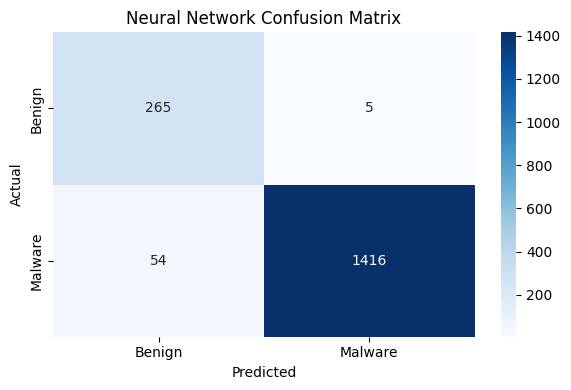

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.title(f"{MODEL_NAME} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

**Note:** The feature importance below is computed as a fast heuristic proxy (sum of absolute weights in the first Dense layer). It is not a true feature attribution as it ignores interaction effects and later layers. For rigorous attribution, use SHAP.

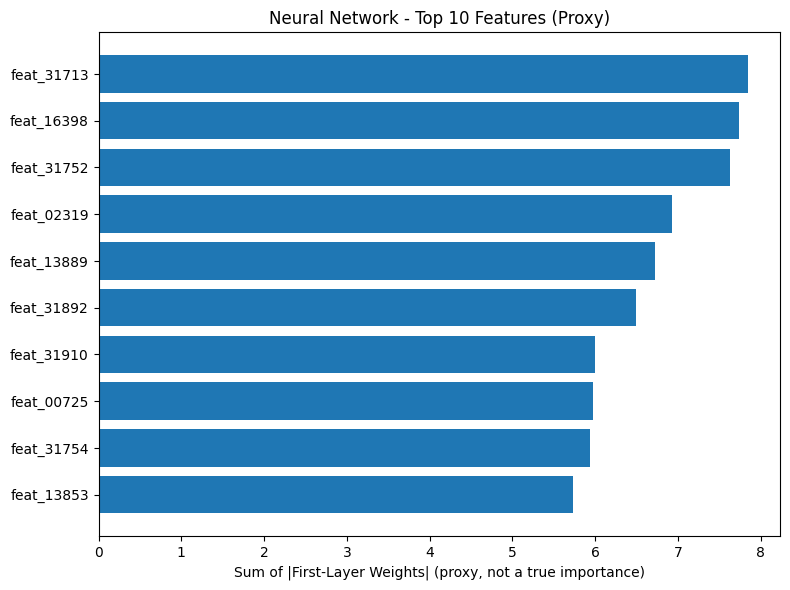

In [12]:
TOP_K_FEATURES = 10
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Extract first Dense layer weights
dense_layer = None
for layer in model.layers:
    if 'dense' in layer.name.lower():
        dense_layer = layer
        break

weights = dense_layer.get_weights()[0]
importance = np.abs(weights).sum(axis=1)

df_imp = pd.DataFrame({'feature': feature_cols, 'importance': importance})
df_imp = df_imp.sort_values('importance', ascending=False).head(TOP_K_FEATURES)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['feature'][::-1], df_imp['importance'][::-1])
plt.xlabel('Sum of |First-Layer Weights| (proxy, not a true importance)')
plt.title('Neural Network - Top 10 Features (Proxy)')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()